# Paquetes

In [1]:
using PhysicalConstants
using PhysicalConstants.CODATA2022: ħ, m_e, c_0
using Unitful
using Plots
using CSV
using DataFrames

# Funciones

In [5]:
function Kronig_Penney(E, ω, b, V₀; m_eff = 0.023, normalizado = false, compacto = false)
    
    a = ω + b
    
    # estas dos variables las añado para que el coseno de k₁ y k₂ no haga overflow
    mₑc² = ustrip(uconvert(u"eV", m_e*c_0^2))                 # en EV
    ħc = ustrip(uconvert(u"eV*nm", ħ*c_0))                    # en eV nm

    k₁ = @. sqrt(2 * m_eff * mₑc² * E) / ħc                   # en nm⁻¹
    k₂ = @. sqrt(Complex(2 * m_eff * mₑc² * (E - V₀))) / ħc   # en nm⁻¹
    
    # Valor de cos(ka), con esto vemos las bandas imponiendo que f este entre -1 y +1
    f = @. cos(k₁*ω)*cos(k₂*b) - ((k₁^2 + k₂^2) / (2 * k₁ * k₂)) * sin(k₁*ω)*sin(k₂*b)
    
    banda = real.(f)
    
    k_eff, E_eff = Calcular_k(E, banda, a, normalizado, compacto)
    
    return banda, k_eff, E_eff
end



function Calcular_k(E, band, a, normalizar, compactar)
    
    Es = []
    ks = []
    counter = -0.5 * !compactar
    
    for i in 2:length(band)
        if ((abs(band[i]) < 1.0) ⊻ (abs(band[i-1]) < 1.0))
            counter += 0.5 * !compactar
        end
        if (abs(band[i]) <= 1.0)
            push!(Es, E[i])
            if normalizar
                push!(ks, (1 - 2 * !es_par(counter)) * (acos(band[i])/π) + es_entero(counter) * (counter + !es_par(counter)))           # en unidades de π/a
            else
                push!(ks, (1 - 2 * !es_par(counter)) * (acos(band[i])/a) + es_entero(counter) * (counter + !es_par(counter) ) * π / a)  # k en nm⁻¹
            end
        end
    end
    
    return ks, Es
end

function es_par(x)
    return x % 2 == 0
end

function es_entero(x)
    return x % 1 == 0
end

es_entero (generic function with 1 method)

# Datos

In [6]:
Energy = 0:0.00001:1.0
Barrier_Potential = 0.4
Barrier_width = 15.0
Well_width = 10.0
banda, k_bandas, E_bandas = Kronig_Penney(Energy,Well_width,Barrier_width,Barrier_Potential, normalizado = true, compacto = false)

([NaN, 2746.069305458981, 2745.3070002528584, 2744.544858218881, 2743.7828793279305, 2743.021063550896, 2742.259410858672, 2741.497921222147, 2740.736594612236, 2739.9754309998434  …  -0.47673211400791377, -0.47662849698086285, -0.4765248746858026, -0.4764212471241802, -0.47631761429745434, -0.47621397620707573, -0.4761103328544942, -0.4760066842411681, -0.4759030303685439, -0.475799371238082], Any[0.08205018492917195, 0.15951326983389194, 0.2115530360087258, 0.25438449940374197, 0.2921817355387107, 0.326793713684671, 0.35924432924464117, 0.39018242370444434, 0.4200614093958486, 0.44922483278360403  …  5.341821178713818, 5.341858697991976, 5.34189621677991, 5.34193373507771, 5.341971252885465, 5.342008770203262, 5.342046287031193, 5.342083803369345, 5.34212131921781, 5.342158834576673], Any[0.08073, 0.08074, 0.08075, 0.08076, 0.08077, 0.08078, 0.08079, 0.0808, 0.08081, 0.08082  …  0.99991, 0.99992, 0.99993, 0.99994, 0.99995, 0.99996, 0.99997, 0.99998, 0.99999, 1.0])

# Gráficos

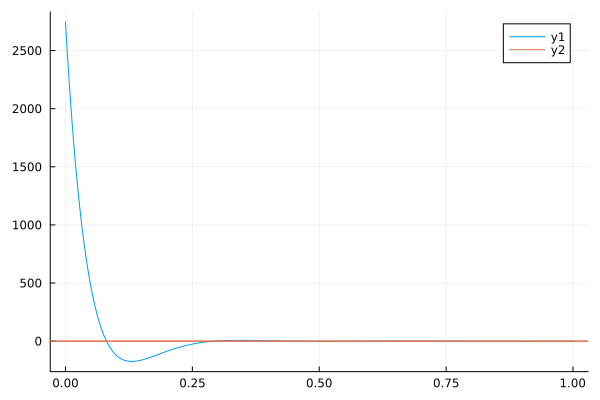

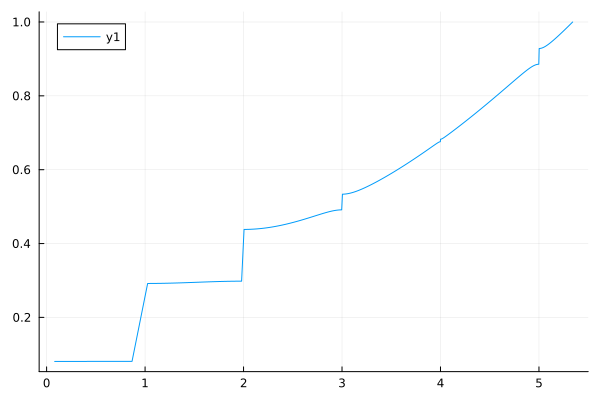

In [7]:
p1 = plot(Energy, banda)
hline!([1.0, -1.0])
p2 = plot(k_bandas,E_bandas)

display(p1)
display(p2)

In [22]:
#################################
# ESTO NO FUNCIONA BIEN TODAVIA #
#################################
function leer_archivo_csv(carpeta, archivo; usuario = "JRcodes73")
    ruta = joinpath(@__DIR__, "..", carpeta, archivo)
    ruta = normpath(ruta)
    # l_ruta = length(archivo)
    # posible_usuario = archivo[l_ruta-length(usuario):l_ruta-1]
    # if posible_usuario == usuario
    #     exit
    # end
    println(ruta)
    data = CSV.read(ruta, DataFrame, header = 4)
    return data
end
prueba = leer_archivo_csv("Pruebas", "200_pozos_04.txt")

c:\Users\diego\OneDrive - UNIVERSIDAD DE GRANADA\GRADO_FISICA\GNOMOS\Diegod\Pruebas\200_pozos_04.txt


ArgumentError: ArgumentError: "c:\Users\diego\OneDrive - UNIVERSIDAD DE GRANADA\GRADO_FISICA\GNOMOS\Diegod\Pruebas\200_pozos_04.txt" is not a valid file or doesn't exist

In [23]:
ocurrencia_to_k = (prueba.Occurrence .- 0.5) ./ 200

UndefVarError: UndefVarError: `prueba` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [24]:
plot!(p2, ocurrencia_to_k, prueba[:,2])


UndefVarError: UndefVarError: `ocurrencia_to_k` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

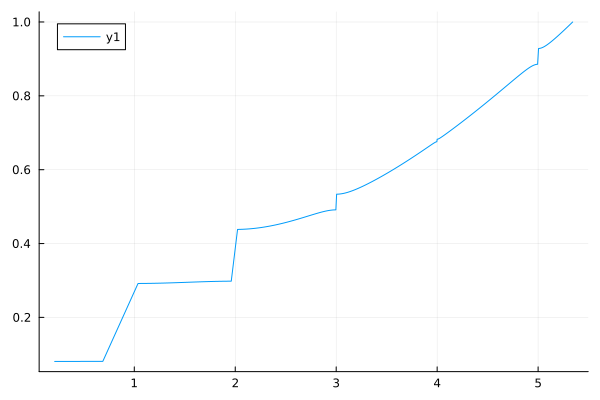

In [25]:
display(p2)